# PFDA Project: E-Commerce & Consumer Behaviour

According to [IBM](https://www.ibm.com/think/topics/customer-analytics), customer analytics is about using customer data to understand what people want. This information guides everything a company does, from marketing to product updates, to making customers' experiences better. By improving these interactions, companies can attract more customers, increase sales, and build loyalty.

Customer analytics are important to help companies making smarter, faster decisions by understanding their customers' habits and needs. Using data like purchase history and feedback, businesses can see what is working, personalise their marketing, and focus on keeping their best customers. This leads to better products, more effective advertising, and happier customers, which helps companies becoming more profitable.

### About the File

This dataset contains detailed consumer behavior data, including purchasing habits, demographics, and preferences, making it ideal for market research, segmentation, and predictive analysis.

**Main Features:**
* Customer Demographics, Purchase Behavior, Customer Loyalty, Feedback, Decision-Making and Influences on Purchase.

Source: [Customer Shopping Trends Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset)

### Why was this chosen? 

This dataset is the perfect foundation for my project, aligning directly with my academic focus and general interest. With a BSc in Marketing and an MSc in Digital Marketing — in which I specialised in strategy — I feel compelled to translate data into a decision making tool and a competitive advantage. 

I am also fascinated by why people make the decisions they do. This file provides the material to answer behavioural questions, allows me to build predictive models and strategic insights that describe and anticipate behaviour.

## Part 1: Importing Databases & Loading the Data

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os

# Visualisation libraries
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Scikit-learn for modeling
from sklearn.linear_model import LinearRegression

# Geolocation and date handling
from geopy.geocoders import Nominatim
import geonamescache as gc

# Machine learning library
from datetime import datetime


# Confirmation message
print("Libraries loaded successfully!")

Libraries loaded successfully!


### Data Retrieval and Loading 

In [2]:
# Loading the CSV file
FILENAME = "Ecommerce_Consumer_Behavior_Analysis_Data.csv"
DATADIR = "data/"
FULLPATH = DATADIR + FILENAME

# Read the CSV file into a DataFrame with error handling
if os.path.exists(FULLPATH):
	df = pd.read_csv(FULLPATH, encoding='utf-8')
	print(f"Dataset shape: {df.shape}")
else:
	print(f"File not found: {FULLPATH}")
	print("Please check the file path and ensure the data directory exists")

# Display the first few rows of the DataFrame
display(df.head())

Dataset shape: (1000, 28)


,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [3]:
# DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

From the results above, I am aware that there are NaN cells within the DataFrame, especifically in the 'Social Media Influence' and ' Engagement with Ads' Columns.

### Part 2: Cleaning the Data

Transforming column data into numerical value as it can be included in  the analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

**Handling Missing values:**

In [5]:
# Checking for missing values
num_cols = df.select_dtypes(include=np.number).columns

# Identify categorical columns
categ_cols = df.select_dtypes(exclude=np.number).columns

# Impute missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[categ_cols] = df[categ_cols].fillna(df[categ_cols].mode().iloc[0])

# Verify no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Customer_ID                              0
Age                                      0
Gender                                   0
Income_Level                             0
Marital_Status                           0
Education_Level                          0
Occupation                               0
Location                                 0
Purchase_Category                        0
Purchase_Amount                          0
Frequency_of_Purchase                    0
Purchase_Channel                         0
Brand_Loyalty                            0
Product_Rating                           0
Time_Spent_on_Product_Research(hours)    0
Social_Media_Influence                   0
Discount_Sensitivity                     0
Return_Rate                              0
Customer_Satisfaction                    0
Engagement_with_Ads                      0
Device_Used_for_Shopping                 0
Payment_Method                           0
Time_of_Purchase     

Does my data have any outliers?

Outliers are data points that differ significantly from the rest of the dataset, often arising from measurement errors, rare events, or inherent data variability. If not addressed, they can distort analysis, skew statistical results, and impair machine learning models.

Common sources include measurement or data entry errors, sampling issues, and natural variation in the data. Outliers may also result from experimental flaws, mixing data from different populations, or even intentional insertion to test a model's robustness. Understanding these origins helps determine whether to correct, adjust, or retain the outlier during analysis.

Source: [GeeksforGeeks](https://www.geeksforgeeks.org/data-science/detect-and-remove-the-outliers-using-python/)

Remove outliers using [IQR](https://www.geeksforgeeks.org/machine-learning/interquartile-range-to-detect-outliers-in-data/), for accuracy:



In [6]:
# Let's check if the data contains any outliers in numeric columns
# And we'll include the Purchase_Amount column in the analysis, as it's numeric now

for col in num_cols: 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}")

Number of outliers in Age: 0
Number of outliers in Frequency_of_Purchase: 0
Number of outliers in Brand_Loyalty: 0
Number of outliers in Product_Rating: 0
Number of outliers in Time_Spent_on_Product_Research(hours): 0
Number of outliers in Return_Rate: 0
Number of outliers in Customer_Satisfaction: 0
Number of outliers in Time_to_Decision: 0


* We'll also convert the date and time column into a fixed format

In [7]:
# Convert 'Time_of_Purchase' to datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')

The "Location" column seem to have too many different cities, which can be difficult to profile our customers. We'll group them bu countries, as it is  easier to manipulate the data, using geopy.geocoders (Nominatim)

Source: [GeeksforGeeks](https://www.geeksforgeeks.org/python/get-the-city-state-and-country-names-from-latitude-and-longitude-using-python/)

In [8]:
# First, let's see what locations we have
unique_locations = df['Location'].str.lower().unique()
print(f"Number of unique locations: {len(unique_locations)}")

Number of unique locations: 969


In [9]:
# Build a city to country mapping using geonamescache
gc = gc.GeonamesCache()

cities = gc.get_cities()
countries = gc.get_countries()

city_to_country = {city["name"].lower(): countries[city["countrycode"]]["name"]
    for city in cities.values()}

In [10]:
# Map locations to countries
df["Country"] = (df["Location"].str.lower().map(city_to_country))

In [11]:
# For any unmapped locations, we can use geopy as a fallback
# This may take some time due to rate limiting
from geopy.geocoders import Nominatim
from time import sleep

geolocator = Nominatim(user_agent="ecommerce_analysis")

def geopy_country_fallback(city):
    try:
        loc = geolocator.geocode(city, addressdetails=True)
        if loc and "country" in loc.raw["address"]:
            return loc.raw["address"]["country"]
    except:
        pass
    return None

In [12]:
# Apply fallback only where needed:

mask = df["Country"].isna()

for idx in df[mask].index:
    country = geopy_country_fallback(df.at[idx, "Location"])
    if country:
        df.at[idx, "Country"] = country
    sleep(1)  # Respect Nominatim usage policy

In [13]:
# Drop rows where location could not be standardised
df = df.dropna(subset=["Country"])

# Verification of standardised locations
print("Sample of standardized locations:")
print(df[["Location", "Country"]].head(10))

Sample of standardized locations:
      Location                   Country
0         Évry                    France
1     Huocheng                     China
2       Huzhen                        中国
3       Wiwilí                 Nicaragua
4         Nara                      Mali
5   Boro Utara  South Sudan جنوب السودان
6        Liren                        中国
7     Taocheng                        中国
8        Gråbo                   Sverige
9  Pryamitsyno                    Россия


And we'll create group ages, for a cleaner analysis

In [14]:
# First create Age_Group from Age column
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# And now we'll plot the age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_counts

Age_Group
18-25    212
26-35    296
36-45    296
46-55    142
55+        0
Name: count, dtype: int64

In [62]:
# Group by Genders and calculate the average purchase amount
if 'df' in locals():
	# Check if Purchase_Amount is object type (string), if so convert it
	if df['Purchase_Amount'].dtype == 'object':
		df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$', '').astype(float).round(2)
	
	result = df.groupby('Gender')['Purchase_Amount'].mean()
	print("Average Purchase Amount by Gender:")
	print(result)
else:
	print("DataFrame 'df' not found. Please run cells 4 and 9 first to load and clean the data.")

Average Purchase Amount by Gender:
Gender
Female   279.85
Male     266.83
Other    277.85
Name: Purchase_Amount, dtype: float64


In [63]:
# Swapping any other gender that is not Female or Male into Other
df['Gender'] = df['Gender'].apply(lambda x: x if x in ['Female', 'Male'] else 'Other') # Standardising gender
print("Unique genders after grouping:", df['Gender'].unique())

Unique genders after grouping: ['Female' 'Male' 'Other']


In [17]:
# Saving cleaned data to a new CSV file  for easy access later
CLEAN_FILENAME = "Consumer_Behavior_Clean.csv"
CLEAN_FULLPATH = "data/" + CLEAN_FILENAME
df.to_csv(CLEAN_FULLPATH, index=False)
print(f"Cleaned data saved to: {CLEAN_FULLPATH}")

Cleaned data saved to: data/Consumer_Behavior_Clean.csv


### Part 3: Exploring the data

In [64]:
# Statistical summary of the DataFrame (taking into account only numerical columns)
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Age,Purchase_Amount,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_of_Purchase,Time_to_Decision,Month,Cost_per_Transaction
count,946.00,946.00,946.00,946.00,946.00,946.00,946.00,946.00,946,946.00,946.00,946.00
mean,34.21,273.81,6.93,3.02,3.03,1.02,0.95,5.42,2024-06-27 07:54:55.560253952,7.55,6.38,53.13
min,18.00,50.71,2.00,1.00,1.00,0.00,0.00,1.00,2024-01-01 00:00:00,1.00,1.00,4.23
25%,26.00,161.94,4.00,2.00,2.00,0.00,0.00,3.00,2024-04-04 00:00:00,4.00,4.00,22.66
50%,34.00,272.12,7.00,3.00,3.00,1.00,1.00,6.00,2024-06-28 00:00:00,8.00,6.00,41.11
75%,42.00,385.26,10.00,4.00,4.00,2.00,2.00,8.00,2024-09-17 00:00:00,11.00,9.00,65.25
max,50.00,498.33,12.00,5.00,5.00,2.00,2.00,10.00,2024-12-30 00:00:00,14.00,12.00,249.16
std,9.36,131.24,3.16,1.42,1.44,0.79,0.81,2.85,NaN,4.05,3.29,45.02


#### Descriptive Analysis

* **Who are my customers? (Demographics, age, gender, location, income, occupation)**

In [65]:
# What is the average age of customers?
average_age = df['Age'].mean()
print(f"The average age of customers is: {average_age:.2f} years")

The average age of customers is: 34.21 years


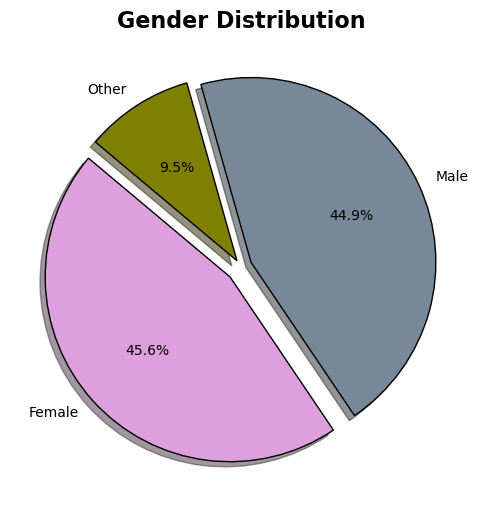

In [ ]:
# Then,by gender distribution via a pie chart
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(12,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['plum', 'lightslategray', 'olive'],
        wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=140, explode=[0.08, 0.06, 0.04])
plt.title("Gender Distribution", fontsize=16, fontweight='bold')

plt.show()

In [ ]:
# Average purchase amount by age group (excluding 55+ as there are no customers)
age_group_perf = df.groupby('Age_Group', observed=False)['Purchase_Amount'].mean()
age_group_perf = age_group_perf.drop('55+')  # Remove 55+ group as there are no customers

age_group_perf

Age_Group
18-25   276.74
26-35   278.45
36-45   271.59
46-55   264.36
Name: Purchase_Amount, dtype: float64

In [74]:
# Purchasing amounts per age group 
df_sorted = df.sort_values('Purchase_Amount')
fig = px.box(df_sorted, x='Age_Group', y='Purchase_Amount', color='Age_Group', title='Purchase Amount Distribution by Age Group')
fig.update_layout(width=1300, height=800)

fig.show()

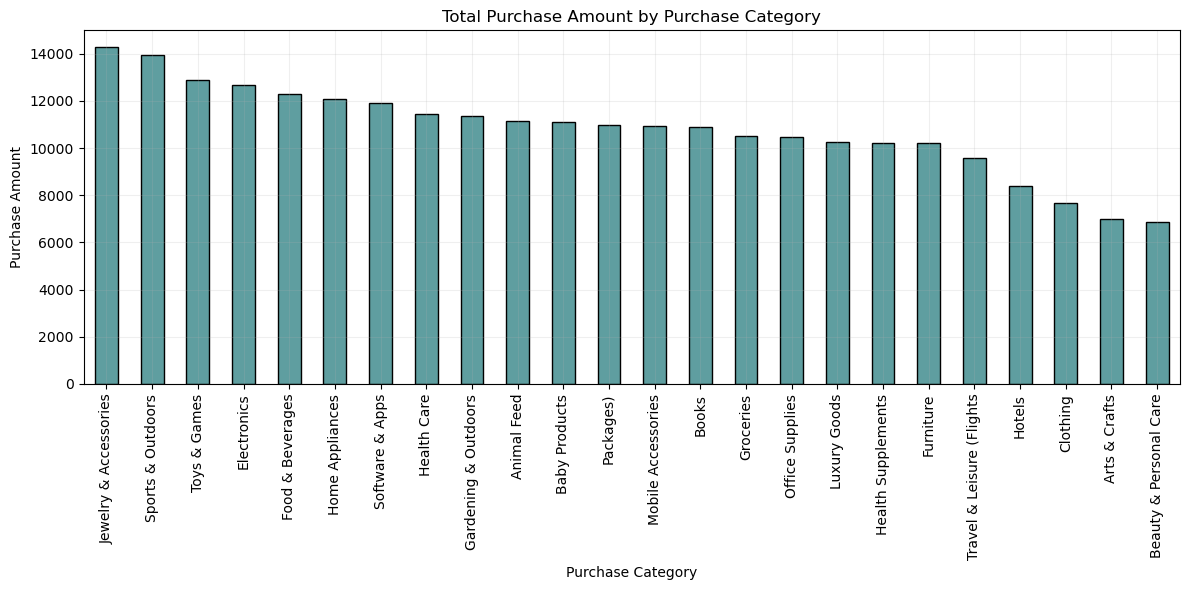

In [75]:
# Category Revenue Contribution
plt.figure(figsize=(12, 6))
df.groupby("Purchase_Category")["Purchase_Amount"].sum().sort_values(ascending=False).plot(kind="bar", color='cadetblue', edgecolor='black')

# Formatting the plot
plt.title("Total Purchase Amount by Purchase Category")
plt.ylabel("Purchase Amount")
plt.xlabel("Purchase Category")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Frequency and Distribution Analysis

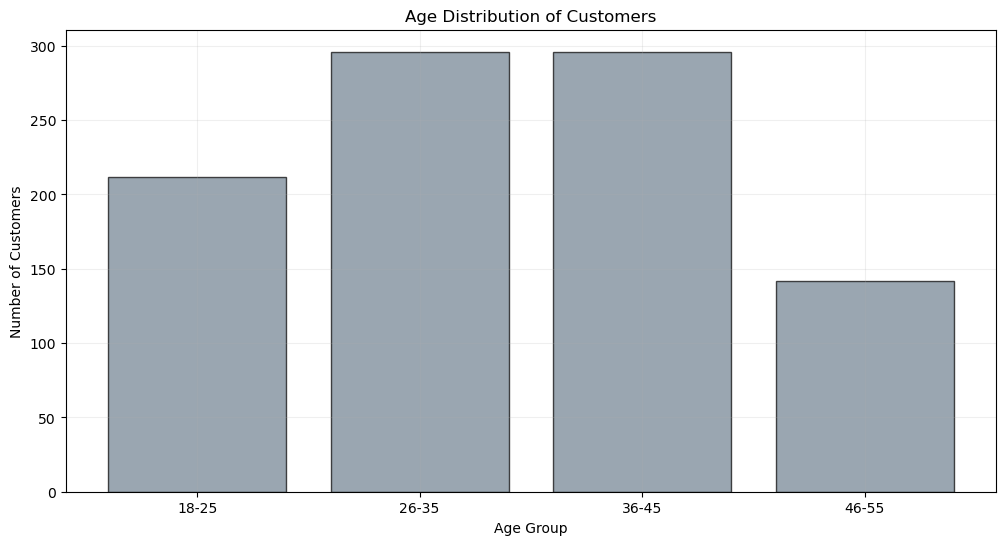

In [76]:
# To better view our customer groups, let's start profiling our customers by age groups
plt.figure(figsize=(12, 6))
age_group_counts = df['Age_Group'].value_counts().sort_index()

# And we'll remove the 55+ group for better visualisation, as there are no customers in that group
age_group_counts = age_group_counts.drop('55+')

plt.bar(age_group_counts.index, age_group_counts.values, color='slategray', edgecolor='black', alpha=0.7)
plt.title('Age Distribution of Customers')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.show()

In [77]:
# Which Shopping Channel is preferred by different Genders?
# 'Gender' and 'Purchase Channel' relationship 
pd.crosstab(df['Gender'], df['Purchase_Channel'], normalize=True).round(4)* 100 # Show rounded percentages

Purchase_Channel,In-Store,Mixed,Online
Gender,,,
Female,14.59,15.43,15.54
Male,15.64,15.01,14.27
Other,2.75,3.28,3.49


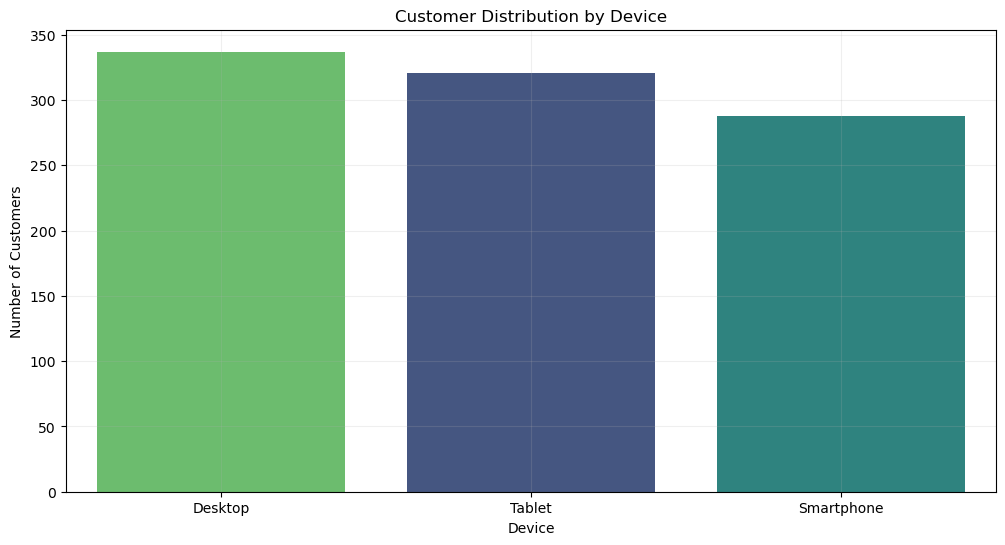

In [26]:
# What device do they access the platform from?
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Device_Used_for_Shopping', order=df['Device_Used_for_Shopping'].value_counts().index, palette='viridis', hue='Device_Used_for_Shopping')
plt.title('Customer Distribution by Device')
plt.xlabel('Device')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.show()

In [27]:
# Now, we'll group by genders and calculate the average purchase amount
# We'll also include if each gender engages with ads
gender_perf = df.groupby('Gender', observed=False).agg({'Engagement_with_Ads': lambda x: x.value_counts().index[0]
						 if len(x.value_counts()) > 0
						 else 'No Data','Purchase_Amount': 'mean'})
gender_perf

,Engagement_with_Ads,Purchase_Amount
Gender,,
Female,High,279.85
Male,High,266.83
Other,High,277.85


In [28]:
# We'll also look at age groups performance by averaging purchase amount
# And we'll remove the 55+ group for better visualisation, as there are no customers in that group
age_group_perf = df.groupby('Age_Group', observed=False)['Purchase_Amount'].mean()
age_group_perf = age_group_perf.drop('55+')  # Remove 55+ group as there are no customers
age_group_perf


Age_Group
18-25   276.74
26-35   278.45
36-45   271.59
46-55   264.36
Name: Purchase_Amount, dtype: float64

c:\Users\35387\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.

c:\Users\35387\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.



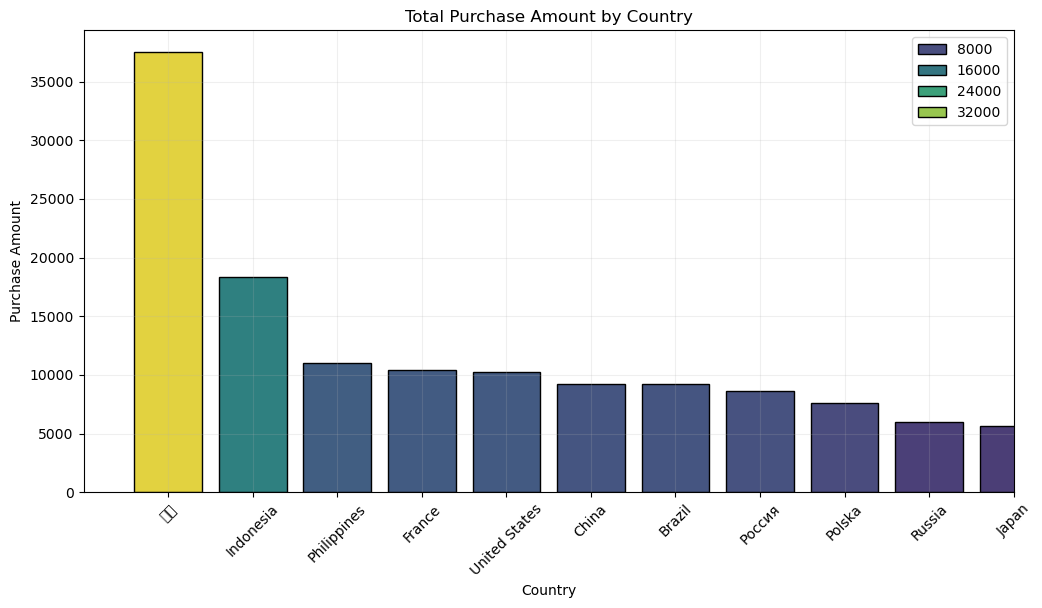

In [29]:
# Revenue by Country
# Group by Country and sum Purchase_Amount
country_counts = df.groupby("Country")["Purchase_Amount"].sum().sort_values(ascending=False)

# Plotting the total purchase amount by country
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis', edgecolor='black', hue=country_counts.values)
plt.title("Total Purchase Amount by Country")
plt.ylabel("Purchase Amount")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

# To avoid a very cluttered plot, we'll show only the top 10 most profitable countries,
# in our dataset, to the organisation
plt.xlim(-1, 10)
plt.show()

* **What are they doing? (Behavioral)**

* How do they browse and buy? (Frequent browsers, cart abandoners, first-time vs. repeat buyers).

In [30]:
# Creating boxplots of Purchase Amount by Purchase Intent
fig = px.box(df, x='Purchase_Intent', y='Purchase_Amount', color='Purchase_Intent', title='Purchase Amount by Purchase Intent')
fig.update_layout(width=1200, height=600)
fig.update_traces(marker=dict(line=dict(width=0.5)))
fig.show()

* What convinced them to buy? (Valued features, trust signals). 

In [31]:
# How many customers, in percentage, are repeat buyers?
# Create repeat buyer indicator based on frequency of purchase
df['Repeat_Buyer'] = df['Frequency_of_Purchase'] > 1
repeat_buyer_counts = df['Repeat_Buyer'].value_counts(normalize=True) * 100
repeat_buyer_counts

Repeat_Buyer
True   100.00
Name: proportion, dtype: float64

In [32]:
# How many, in percentage terms, are members of our loyalty program?
loyalty_counts = df['Customer_Loyalty_Program_Member'].value_counts(normalize=True).round(4) * 100
loyalty_counts

Customer_Loyalty_Program_Member
False   50.85
True    49.15
Name: proportion, dtype: float64

In [33]:
# How many customers are highly satisfied (rating of 4 or more)?
highly_satisfied_counts = (df['Customer_Satisfaction'] >= 4).value_counts(normalize=True).round(3) * 100
highly_satisfied_counts

Customer_Satisfaction
True    68.90
False   31.10
Name: proportion, dtype: float64

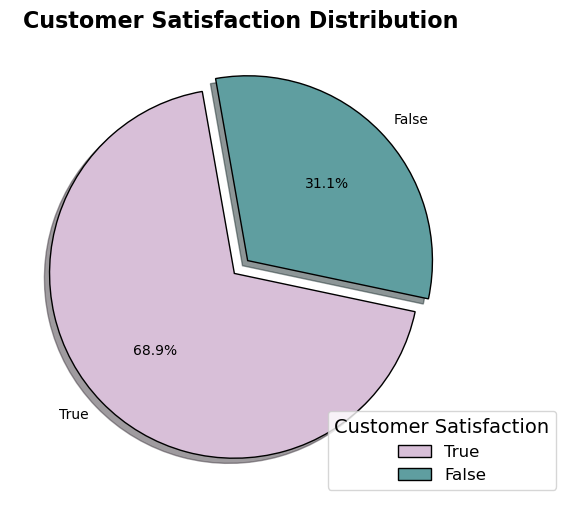

In [34]:
# And now for the big reveal, we'll plot the pie chart with nice colours and black edges to enhance visualisation
plt.figure(figsize=(12,6))
plt.pie(highly_satisfied_counts, labels=highly_satisfied_counts.index, autopct='%1.1f%%', colors=['thistle', 'cadetblue'],
        wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=100,
        explode=[0.05]*len(highly_satisfied_counts))

# We'll add 3D effect to the pie chart
plt.gca().set_aspect('equal')  # Ensures that pie is drawn as a circle
plt.title("Customer Satisfaction Distribution", fontsize=16, fontweight='bold')
plt.legend(title="Customer Satisfaction", fontsize=12, title_fontsize=14, loc='lower right', bbox_to_anchor=(1.2, 0))

plt.show()

# Source: https://matplotlib.org/stable/gallery/color/named_colors.html

* What are their values, interests, or lifestyle? (Personality traits, tech adoption).
* How did they first hear about us? (Marketing channel effectiveness). **(Discount and advertising)**

**Customer Segmentation**

*  **Where are they coming from? (Channel & Journey) and which marketing channel is performing the best? Social or email or search etc. Performance is usually a rate of some kind - conversion rate or ROI.**

In [35]:
# Now we'll analyse the relationship between device usage and social media influence
if 'Social_Media_Influence' in df.columns:
	device_social_media = df.groupby('Device_Used_for_Shopping')['Social_Media_Influence'].value_counts(normalize=True).unstack().fillna(0).round(4) * 100
	print("\nDevice usage vs Social Media Influence:")
	print(device_social_media)
else:
	print("\nNo social media related column found. Showing device distribution instead:")
	device_distribution = df['Device_Used_for_Shopping'].value_counts()
	print(device_distribution)


Device usage vs Social Media Influence:
Social_Media_Influence    High   Low  Medium
Device_Used_for_Shopping                    
Desktop                  47.18 29.97   22.85
Smartphone               53.82 22.22   23.96
Tablet                   54.21 21.81   23.99


### Relationship Analysis

In [36]:
# Checking if there is correlation batween age and purchase frequency
correlation = df['Age'].corr(df['Frequency_of_Purchase'])
correlation

-0.05346565742854491

In [37]:
# Checking if people who browse more frequently tend to spend more
correlation_browse_spend = df['Time_to_Decision'].corr(df['Purchase_Amount'])
correlation_browse_spend

0.01720041268480891

In [38]:
# Create age group vs category purchase analysis
age_group_category_purchase = pd.crosstab(df['Age_Group'], df['Purchase_Category'], normalize='index').round(4) * 100

# Transpose to match the structure of gender_category_purchase
age_group_category_purchase = age_group_category_purchase.T

# Check the top 3 categories per age group
top_cat_age_group = age_group_category_purchase.apply(lambda x: x.nlargest(3).index.tolist(), axis=0)
top_cat_age_group

Age_Group,18-25,26-35,36-45,46-55
0,Mobile Accessories,Gardening & Outdoors,Jewelry & Accessories,Toys & Games
1,Sports & Outdoors,Home Appliances,Electronics,Food & Beverages
2,Office Supplies,Animal Feed,Furniture,Sports & Outdoors


In [39]:
# Are certain genders more likely to buy specific categories?
gender_cat_purchase = pd.crosstab(df['Gender'], df['Purchase_Category'], normalize='index').round(4) * 100

# Swapping columns for rows, for better visualisation
gender_cat_purchase = gender_cat_purchase.T
gender_cat_purchase

Gender,Female,Male,Other
Purchase_Category,,,
Animal Feed,4.87,4.47,3.33
Arts & Crafts,3.71,2.82,4.44
Baby Products,4.41,4.47,2.22
Beauty & Personal Care,3.71,2.82,1.11
Books,3.48,4.94,0.00
Clothing,2.32,3.06,4.44
Electronics,6.03,4.47,6.67
Food & Beverages,4.64,4.24,4.44
Furniture,4.64,3.76,4.44


In [40]:
# Top 3 categories per gender
top_cats = gender_cat_purchase.apply(lambda x: x.nlargest(3).index.tolist(), axis=0)
top_cats

Gender,Female,Male,Other
0,Jewelry & Accessories,Home Appliances,Packages)
1,Electronics,Sports & Outdoors,Electronics
2,Toys & Games,Gardening & Outdoors,Home Appliances


C:\Users\35387\AppData\Local\Temp\ipykernel_10144\148027877.py:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



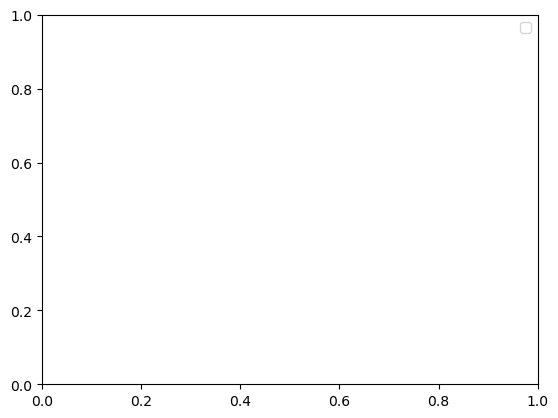

In [41]:
# Is there a correlation between customer satisfaction and gender?
df.groupby('Gender')['Customer_Satisfaction'].mean()

px.box(df, x='Gender', y='Customer_Satisfaction', title='Satisfaction by Gender')
plt.legend()



In [42]:
# Does discounting lead to higher customer satisfaction?
# Check the average satisfaction for discounted vs non-discounted purchases
discount_satisfaction = df.groupby('Discount_Used')['Customer_Satisfaction'].mean()
discount_satisfaction

# Now we'll check for correlation
correlation_discount_satisfaction = df['Discount_Used'].map({'Yes': 1, 'No': 0, 'Other: NaN': None}).corr(df['Customer_Satisfaction'])
correlation_discount_satisfaction

nan

### Operational & Financial Questions

•	What's our cost per acquisition (CPA) and cost per transaction?

•	what is the best user experience? Usually measured in how quickly or how often the user completes their task (usually the task is making a purchase). Look at conversion rate, time on site, time to purchase, and also A/B (hypothesis) tests are great for analysis.

•   Which customers generate more value? How can we attract more of them? How can we convert other customers to spend more?

•   Average order value (AOV) - Use AOV to track the average amount of money customers spend on each purchase, whether it’s their first order or they’re a returning customer. Combine this with the average number of purchases by each registered customer, and you will be able to get another highly important KPI – Customer Lifetime Value (CLV).

•   Total revenue and Revenue by channel - Different customers approach online shopping in different ways. Tracking revenue breakdown by device, advertising platform, customer location, or any other dimension will allow you to see how your customers are buying your products, and fine-tune your campaigns to improve sales.


In [43]:
# Counting purchases by category
df['Purchase_Category'].value_counts()

Purchase_Category
Electronics                  51
Jewelry & Accessories        48
Sports & Outdoors            48
Home Appliances              46
Toys & Games                 45
Animal Feed                  43
Food & Beverages             42
Gardening & Outdoors         42
Furniture                    40
Baby Products                40
Mobile Accessories           39
Health Care                  39
Health Supplements           39
Packages)                    39
Software & Apps              38
Groceries                    38
Travel & Leisure (Flights    38
Luxury Goods                 37
Office Supplies              37
Books                        36
Hotels                       33
Arts & Crafts                32
Beauty & Personal Care       29
Clothing                     27
Name: count, dtype: int64

In [44]:
###### REVIEW & ADD ROI and BEST CUSTOMERS #######

# Churn Risk (Low purchase frequency, satisfaction, weak loyalty)
#df["Churn_Risk"] = (
   # (df["Frequency_of_Purchase"] <= df["Frequency_of_Purchase"].quantile(0.25)) &
   # (df["Customer_Satisfaction"] <= 2) &
   # (df["Brand_Loyalty"] <= 2)).astype(int)

######

In [45]:
# Converting 'Time_of_Purchase' to datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
df['Time_of_Purchase'].head()

0   2024-03-01
1   2024-04-16
2   2024-03-15
3   2024-10-04
4   2024-01-30
Name: Time_of_Purchase, dtype: datetime64[ns]

In [46]:
# Convert Time_of_Purchase to datetime format first, then extract month
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
df['Month'] = df['Time_of_Purchase'].dt.month

# Count of purchases by month
df['Month'].value_counts().sort_index()

Month
1     72
2     66
3     88
4     96
5     73
6     88
7     88
8     93
9     78
10    72
11    75
12    57
Name: count, dtype: int64

In [47]:
# Calculating total purchases per month
monthly_totals = df.groupby('Month')['Purchase_Amount'].sum().to_frame()
monthly_totals

,Purchase_Amount
Month,
1,18174.45
2,19429.00
3,25635.75
4,27714.15
5,17694.85
6,24859.88
7,23424.75
8,25876.45
9,22435.17


In [48]:
# Now, We'll calculate the cost per transaction over time
df['Cost_per_Transaction'] = df['Purchase_Amount'] / df['Frequency_of_Purchase']
df[['Purchase_Amount', 'Frequency_of_Purchase', 'Cost_per_Transaction']]

,Purchase_Amount,Frequency_of_Purchase,Cost_per_Transaction
0,333.80,4,83.45
1,222.22,11,20.20
2,426.22,2,213.11
3,101.31,6,16.89
4,211.70,6,35.28
...,...,...,...
994,468.16,8,58.52
996,69.78,9,7.75
997,453.37,10,45.34
998,106.15,12,8.85


In [49]:
# First, we'll ensure the month column exists by extracting it from 'Time of Purchase'
if 'Month' not in df.columns:
	df['Month'] = df['Time_of_Purchase'].dt.month

# The highest cost per transaction by month
highest_cost_per_transaction = df.groupby('Month')['Cost_per_Transaction'].max().to_frame()
highest_cost_per_transaction

,Cost_per_Transaction
Month,
1,248.90
2,246.37
3,248.88
4,216.21
5,249.16
6,248.06
7,231.48
8,211.16
9,185.79


C:\Users\35387\AppData\Local\Temp\ipykernel_10144\1522189255.py:8: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



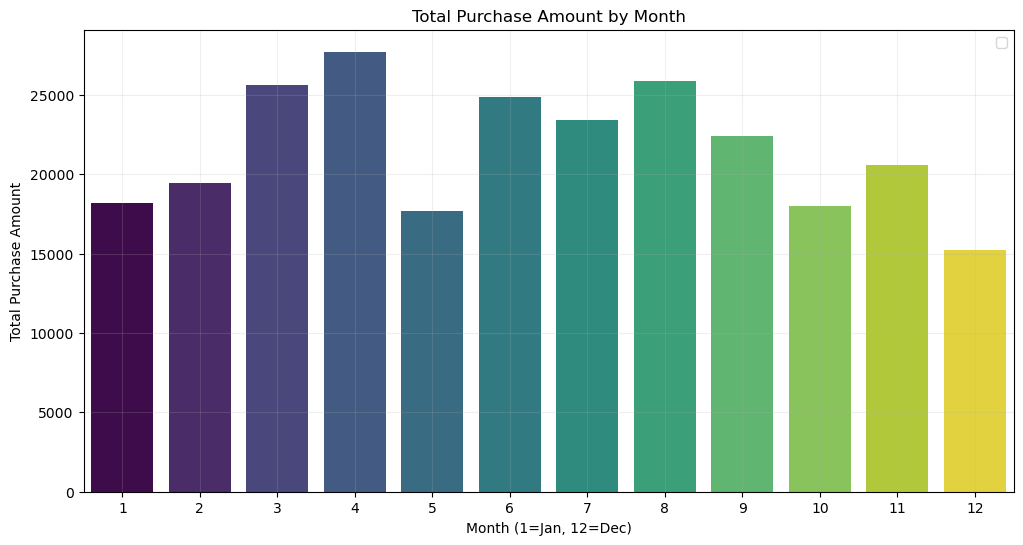

In [50]:
# Visualise the average purchase amount
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_totals.index, y=monthly_totals['Purchase_Amount'], palette='viridis', hue=monthly_totals.index, legend=False)
plt.title('Total Purchase Amount by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Total Purchase Amount')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

•	How effective are our promotions/discounts? 

In [51]:
# How does each age group perform regarding advertisement engagement and purchase amounts?
age_group_performance = df.groupby('Age_Group', observed=False).agg({'Engagement_with_Ads': lambda x: x.value_counts().index[0]
                         if len(x.value_counts()) > 0
                         else 'No Data','Purchase_Amount': 'mean'}) 
age_group_performance

,Engagement_with_Ads,Purchase_Amount
Age_Group,,
18-25,High,276.74
26-35,High,278.45
36-45,High,271.59
46-55,High,264.36
55+,No Data,NaN


### Advanced Analysis

In [52]:
# Projected growth in purchase amount over the next 12 months
# Using a simple linear growth model based on past data
last_month = monthly_totals.index.max()
growth_rate = monthly_totals['Purchase_Amount'].pct_change().mean()

projections = {}
for i in range(1, 13):
    next_month = last_month + i
    projected_amount = monthly_totals['Purchase_Amount'].iloc[-1] * ((1 + growth_rate) ** i)
    projections[next_month] = round(projected_amount, 2) # Only show 2 decimal places
projections

{13: 15357.49,
 14: 15514.04,
 15: 15672.19,
 16: 15831.95,
 17: 15993.34,
 18: 16156.37,
 19: 16321.07,
 20: 16487.44,
 21: 16655.51,
 22: 16825.3,
 23: 16996.81,
 24: 17170.07}

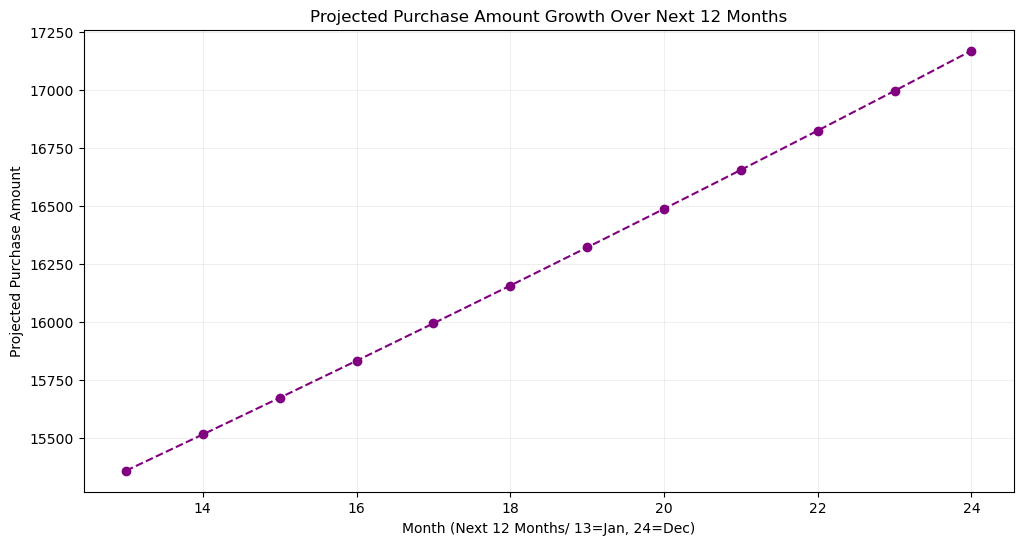

In [53]:
# Now we plot the projected growth
plt.figure(figsize=(12,6))
plt.plot(list(projections.keys()), list(projections.values()), marker='o', linestyle='--', color='purple')
plt.title('Projected Purchase Amount Growth Over Next 12 Months')
plt.xlabel('Month (Next 12 Months/ 13=Jan, 24=Dec)')
plt.ylabel('Projected Purchase Amount')
plt.grid(alpha=0.2)
plt.show()

In [54]:
# First create the payment method statistics DataFrame
payment_method_stats = df.groupby('Payment_Method').agg({'Purchase_Amount': ['mean', 'sum', 'count'], 'Frequency_of_Purchase': 'mean'}).round(2)

# Flatten the column names
payment_method_stats.columns = ['Avg_Purchase', 'Total_Revenue', 'Transaction_Count', 'Avg_Frequency']

# Calculate cost per transaction (Purchase Amount / Frequency)
payment_method_stats['Cost_per_Transaction'] = (payment_method_stats['Avg_Purchase'] / payment_method_stats['Avg_Frequency']).round(2)

# Calculate ROI for each payment method
payment_method_stats['ROI'] = ((payment_method_stats['Avg_Purchase'] - payment_method_stats['Cost_per_Transaction']) / payment_method_stats['Cost_per_Transaction'] * 100).round(2)

payment_method_stats

,Avg_Purchase,Total_Revenue,Transaction_Count,Avg_Frequency,Cost_per_Transaction,ROI
Payment_Method,,,,,,
Cash,275.39,47090.89,171,6.96,39.57,595.96
Credit Card,269.15,49793.20,185,7.12,37.80,612.04
Debit Card,271.26,51538.54,190,6.73,40.31,572.93
Other,280.51,53296.82,190,7.02,39.96,601.98
PayPal,272.87,57302.65,210,6.84,39.89,584.06


In [55]:
# How do most customers pay?
payment_method_counts = df['Payment_Method'].value_counts()
payment_method_counts

Payment_Method
PayPal         210
Debit Card     190
Other          190
Credit Card    185
Cash           171
Name: count, dtype: int64

In [56]:
# Within each age group, what is the average time to decision and purchase intent?
age_group_decision_intent = df.groupby('Age_Group').agg({'Time_to_Decision': 'mean',
    'Purchase_Intent': lambda x: x.value_counts(normalize=True).idxmax() 
    if len(x) > 0 else 'No Data'  # Most common purchase intent
}).round(2)
age_group_decision_intent


C:\Users\35387\AppData\Local\Temp\ipykernel_10144\4011601642.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Time_to_Decision,Purchase_Intent
Age_Group,,
18-25,7.29,Need-based
26-35,7.54,Wants-based
36-45,7.74,Impulsive
46-55,7.58,Wants-based
55+,NaN,No Data


In [57]:
# In percentages, which gender is more likely to use discounts when making purchases?
discount_usage = df.groupby('Gender')['Discount_Used'].mean() * 100
discount_usage

Gender
Female   52.90
Male     50.82
Other    53.33
Name: Discount_Used, dtype: float64

c:\Users\35387\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.

c:\Users\35387\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) DejaVu Sans.



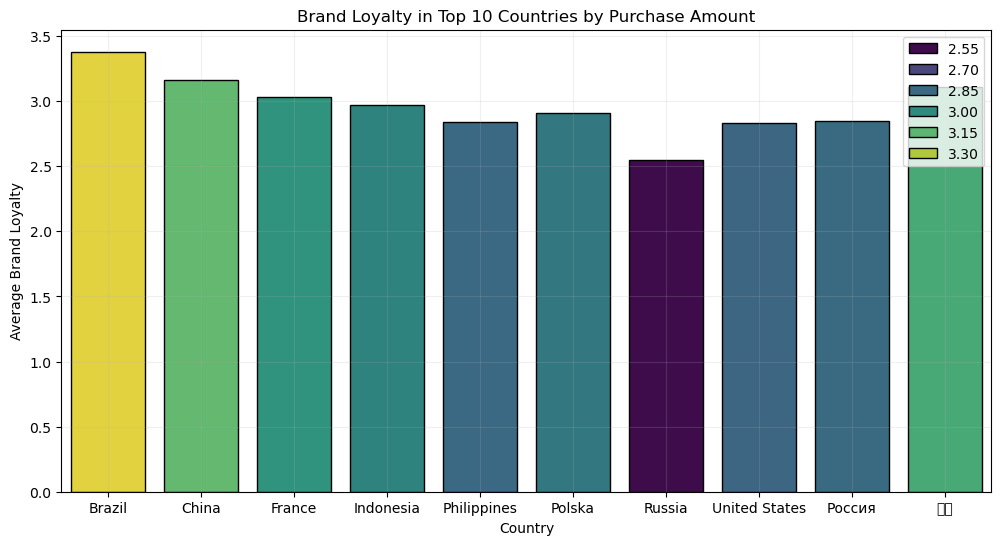

In [58]:
# In percentages, in our top 10 countries by purchase amount, which country has the highest brand loyalty?
top_10_countries = country_counts.head(10).index
top_10_loyalty = df[df['Country'].isin(top_10_countries)].groupby('Country')['Brand_Loyalty'].mean().round(2)

# Plot the brand loyalty of the top 10 countries
plt.figure(figsize=(12,6))
sns.barplot(x=top_10_loyalty.index, y=top_10_loyalty.values, palette='viridis', edgecolor='black', hue=top_10_loyalty.values)
plt.title("Brand Loyalty in Top 10 Countries by Purchase Amount")
plt.ylabel("Average Brand Loyalty")
plt.xlabel("Country")
plt.grid(alpha=0.2)
plt.show()

### Part 5: Conclusion